In [1]:
import pickle
import numpy as np
import pandas as pd
import itertools as it
from pathlib import Path
import matplotlib.pylab as plt
from lameg.util import get_files
import nibabel as nib
from scipy.spatial.distance import euclidean
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec

In [2]:
plt.rcParams.update({
    'font.size': 16,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

In [3]:
def add_subplot_label(ax, label, x=-.21, y=1.225):
    ax.text(x, y, label,  # Adjust left of y-axis
            transform=ax.transAxes,
            fontsize=26, va='top', ha='right')


In [4]:
n_layers = 11
layers = np.arange(n_layers)

In [5]:
def norm_res(mx):
    norm = np.zeros(mx.shape)
    for l in range(mx.shape[1]):
        normed = mx[:,l] - np.min(mx[:,l])
        norm[:,l] = normed
    return norm


def find_peaks(mx, marker="*", return_annot=True):
    annot = np.zeros(mx.shape).astype(np.object_)
    peaks = []
    for l in range(mx.shape[1]):
        peak = np.argmax(mx[:, l])
        annot[peak,l] = 1.0
        peaks.append(peak)
    peaks = np.array(peaks)
    annot_bin = np.copy(annot).astype(float)
    annot[annot==0.0] = None
    annot[annot==1.0] = marker
    if return_annot:
        return peaks, annot, annot_bin
    else:
        return peaks

def bootstrap(data, n_boot=1000, prop=0.5):
    n_rows = data.shape[0]
    rows = np.arange(n_rows)
    prop_rows = int(n_rows*prop)
    results = []
    for b in range(n_boot):
        boot_rows = np.random.choice(rows, size=prop_rows)
        results.append(data[boot_rows])
    return np.array(results)

def shuffled_peak_error(mx, ab=False):
    mx_sh = shuffle_mx(mx)
    peaks = find_peaks(mx_sh, return_annot=False)
    peaks = peaks - np.arange(mx.shape[0])
    if not ab:
        return peaks
    else:
        return np.abs(peaks)


def shuffle_mx(mx):
    mx_shape = mx.shape
    mx = mx.flatten()
    np.random.shuffle(mx)
    return mx.reshape(mx_shape)

In [6]:
sim_types=['base','pink','interference','agm','bem']
sim_type_snr_paths={
    'base': "../output/snr_simulations/",
    'pink': "../output/snr_pink_simulations/",
    'interference': "../output/snr_interference_simulations/",
    'agm': "../output/snr_agm_simulations/",
    'bem': "../output/snr_bem_simulations/",
}
sim_type_coreg_paths={
    'base': "../output/coreg_err_simulations/",
    'pink': "../output/coreg_err_pink_simulations/",
    'interference': "../output/coreg_err_interference_simulations/",
    'agm': "../output/coreg_err_agm_simulations/",
    'bem': "../output/coreg_err_bem_simulations/",
}
sim_type_labels={
    'base': 'Base',
    'pink': 'Pink noise',
    'interference': 'Interfering sources',
    'agm': 'AGM',
    'bem': 'BEM'
}
sim_type_colors={
    'base': np.array([228,26,28])/255.0,
    'pink': np.array([55,126,184])/255.0,
    'interference': np.array([77,175,74])/255.0,
    'agm': np.array([152,78,163])/255.0,
    'bem': np.array([255,127,0])/255.0
}

In [7]:
snr_files={}
coreg_files={}

for sim_type in sim_types:
    snr_res = Path(sim_type_snr_paths[sim_type])
    snr_files[sim_type] = get_files(snr_res, "*.pickle")
    fnms = np.array([[i] + i.stem.split("_") for i in snr_files[sim_type]])
    map_fnms = np.array([i in [1, 3, 5, 6] for i in range(7)])
    fnms = fnms[:,~map_fnms]
    names_ = ["filename", "vx", "snr"]
    snr_files[sim_type] = pd.DataFrame.from_dict(
        {k: fnms[:,i] for i, k in enumerate(names_)}
    )
    snr_files[sim_type]["norm_matrix"] = None
    snr_files[sim_type]["error"] = None
    snr_files[sim_type].vx = snr_files[sim_type].vx.apply(lambda x: eval(x))
    snr_files[sim_type].snr = snr_files[sim_type].snr.apply(lambda x: eval(x))
    mxs = []
    for ix, row in snr_files[sim_type].iterrows():
        with open(row.filename, "rb") as file:
            output = pickle.load(file)
        output = output["layerF"]
        mx = norm_res(output)
        snr_files[sim_type].at[ix, "norm_matrix"] = mx
        peaks, annot, annot_bin = find_peaks(mx, marker=r"$\wedge$")
        snr_files[sim_type].at[ix, "error"] = np.abs(layers - peaks)
        
    coreg_res = Path(sim_type_coreg_paths[sim_type])
    coreg_files[sim_type] = get_files(coreg_res, "*.pickle")
    fnms = np.array([[i] + i.stem.split("_") for i in coreg_files[sim_type]])
    map_fnms = np.array([i in [1, 3, 5, 6] for i in range(7)])
    fnms = fnms[:,~map_fnms]
    names_ = ["filename", "vx", "coreg_error"]
    coreg_files[sim_type] = pd.DataFrame.from_dict(
        {k: fnms[:,i] for i, k in enumerate(names_)}
    )
    coreg_files[sim_type]["norm_matrix"] = None
    coreg_files[sim_type]["error"] = None
    coreg_files[sim_type].vx = coreg_files[sim_type].vx.apply(lambda x: eval(x))
    coreg_files[sim_type].coreg_error = coreg_files[sim_type].coreg_error.apply(lambda x: eval(x))
    mxs = []
    for ix, row in coreg_files[sim_type].iterrows():
        with open(row.filename, "rb") as file:
            output = pickle.load(file)
        output = output["layerF"]
        mx = norm_res(output)
        coreg_files[sim_type].at[ix, "norm_matrix"] = mx
        peaks, annot, annot_bin = find_peaks(mx, marker=r"$\wedge$")
        coreg_files[sim_type].at[ix, "error"] = np.abs(layers - peaks)

In [8]:
snr_range = snr_files[sim_types[-1]].snr.unique()
snr_range.sort()

coreg_range = coreg_files[sim_types[-1]].coreg_error.unique()
coreg_range.sort()

In [9]:
n_permutations = 10000

snr_shuf_error_res=[]

snr_error_res = {
    sim_type: [] for sim_type in sim_types
}
snr_p_values_error = {
    sim_type: [] for sim_type in sim_types
}

coreg_error_shuf_error_res=[]

coreg_error_res = {
    sim_type: [] for sim_type in sim_types
}
coreg_p_values_error = {
    sim_type: [] for sim_type in sim_types
}
for snr in snr_range:
    for sim_type in sim_types:
        matrices = snr_files[sim_type].loc[snr_files[sim_type].snr == snr].norm_matrix.values.tolist()
        
        error = np.array(snr_files[sim_type].loc[snr_files[sim_type].snr == snr].error.to_list())
        error = np.mean(error, axis=-1)
        error_bs = np.mean(bootstrap(error, n_boot=5000), axis=1)
        error_95ci = [np.percentile(error_bs, 2.5), np.percentile(error_bs, 97.5)]
        snr_error_res[sim_type].append([np.mean(error)] + error_95ci)
        
        permuted_error = np.zeros(n_permutations)
        for idx in range(n_permutations):
            rand_mat=matrices[np.random.randint(len(matrices))]
            permuted_error[idx]=np.mean(shuffled_peak_error(rand_mat,ab=True))            
        p_value_error = (np.sum(permuted_error < np.mean(error)) + 1) / (n_permutations + 1)
        snr_p_values_error[sim_type].append(p_value_error)
        
        if sim_type=='base':
            error_95ci_shuf = [np.percentile(permuted_error, 2.5), np.percentile(permuted_error, 97.5)]
            snr_shuf_error_res.append([np.mean(permuted_error)] + error_95ci_shuf)
    
    
for coreg_error in coreg_range:
    for sim_type in sim_types:
        matrices = coreg_files[sim_type].loc[coreg_files[sim_type].coreg_error == coreg_error].norm_matrix.values.tolist()
        
        error = np.array(coreg_files[sim_type].loc[coreg_files[sim_type].coreg_error == coreg_error].error.to_list())
        error = np.mean(error, axis=-1)
        error_bs = np.mean(bootstrap(error, n_boot=5000), axis=1)
        error_95ci = [np.percentile(error_bs, 2.5), np.percentile(error_bs, 97.5)]
        coreg_error_res[sim_type].append([np.mean(error)] + error_95ci)
        
        permuted_error = np.zeros(n_permutations)
        for idx in range(n_permutations):
            rand_mat=matrices[np.random.randint(len(matrices))]
            permuted_error[idx]=np.mean(shuffled_peak_error(rand_mat,ab=True))            
        p_value_error = (np.sum(permuted_error < np.mean(error)) + 1) / (n_permutations + 1)
        coreg_p_values_error[sim_type].append(p_value_error) 
        
        if sim_type=='base':
            error_95ci_shuf = [np.percentile(permuted_error, 2.5), np.percentile(permuted_error, 97.5)]
            coreg_error_shuf_error_res.append([np.mean(permuted_error)] + error_95ci_shuf)

for sim_type in sim_types:
    snr_error_res[sim_type] = np.array(snr_error_res[sim_type])
    snr_p_values_error[sim_type] = np.array(snr_p_values_error[sim_type])
    coreg_error_res[sim_type] = np.array(coreg_error_res[sim_type])
    coreg_p_values_error[sim_type] = np.array(coreg_p_values_error[sim_type])
snr_shuf_error_res=np.array(snr_shuf_error_res)
coreg_error_shuf_error_res=np.array(coreg_error_shuf_error_res)

In [10]:
def diagonal_dominance_score(matrix):
    return np.trace(matrix) / np.sum(matrix)

snr_dds = {
    sim_type: np.zeros(len(snr_range)) for sim_type in sim_types
}
snr_p_vals_dds = {
    sim_type: np.zeros(len(snr_range)) for sim_type in sim_types
}
snr_permuted_dds = np.zeros((len(snr_range), n_permutations))

coreg_dds = {
    sim_type: np.zeros(len(coreg_range)) for sim_type in sim_types
}
coreg_p_vals_dds = {
    sim_type: np.zeros(len(coreg_range)) for sim_type in sim_types
}
coreg_permuted_dds = np.zeros((len(coreg_range), n_permutations))

for s_idx, snr in enumerate(snr_range):
    for sim_type in sim_types:
        matrices = np.array(snr_files[sim_type].loc[snr_files[sim_type].snr == snr].norm_matrix.values.tolist())
        mat=np.mean(matrices,axis=0)
        snr_dds[sim_type][s_idx]=diagonal_dominance_score(mat)

        for idx in range(n_permutations):
            snr_permuted_dds[s_idx,idx] = diagonal_dominance_score(shuffle_mx(mat))

        p_value_dds = (np.sum(np.abs(snr_permuted_dds[s_idx,:] - np.mean(snr_permuted_dds[s_idx,:])) >= np.abs(snr_dds[sim_type][s_idx] - np.mean(snr_permuted_dds[s_idx,:]))) + 1) / (n_permutations + 1)
        snr_p_vals_dds[sim_type][s_idx]=p_value_dds
snr_dds_95ci_shuf = [np.percentile(snr_permuted_dds, 2.5), np.percentile(snr_permuted_dds, 97.5)]
        
for c_idx, coreg_error in enumerate(coreg_range):
    for sim_type in sim_types:
        matrices = np.array(coreg_files[sim_type].loc[coreg_files[sim_type].coreg_error == coreg_error].norm_matrix.values.tolist())
        mat=np.mean(matrices,axis=0)
        coreg_dds[sim_type][c_idx]=diagonal_dominance_score(mat)
        
        for idx in range(n_permutations):
            coreg_permuted_dds[c_idx,idx] = diagonal_dominance_score(shuffle_mx(mat))

        p_value_dds = (np.sum(np.abs(coreg_permuted_dds[c_idx,:] - np.mean(coreg_permuted_dds[c_idx,:])) >= np.abs(coreg_dds[sim_type][c_idx] - np.mean(coreg_permuted_dds[c_idx,:]))) + 1) / (n_permutations + 1)
        coreg_p_vals_dds[sim_type][c_idx]=p_value_dds
coreg_dds_95ci_shuf = [np.percentile(coreg_permuted_dds, 2.5), np.percentile(coreg_permuted_dds, 97.5)]

In [11]:
snr_tick_labels = [f"{i}" for i in snr_range]
snr_tick_labels[0] = r"-$\infty$"
snr_ix = np.arange(snr_range.shape[0])
snr_ix[0] = snr_ix[0] - 1

coreg_tick_labels = [f"{i}" for i in coreg_range]
coreg_error_ix = np.arange(coreg_range.shape[0])

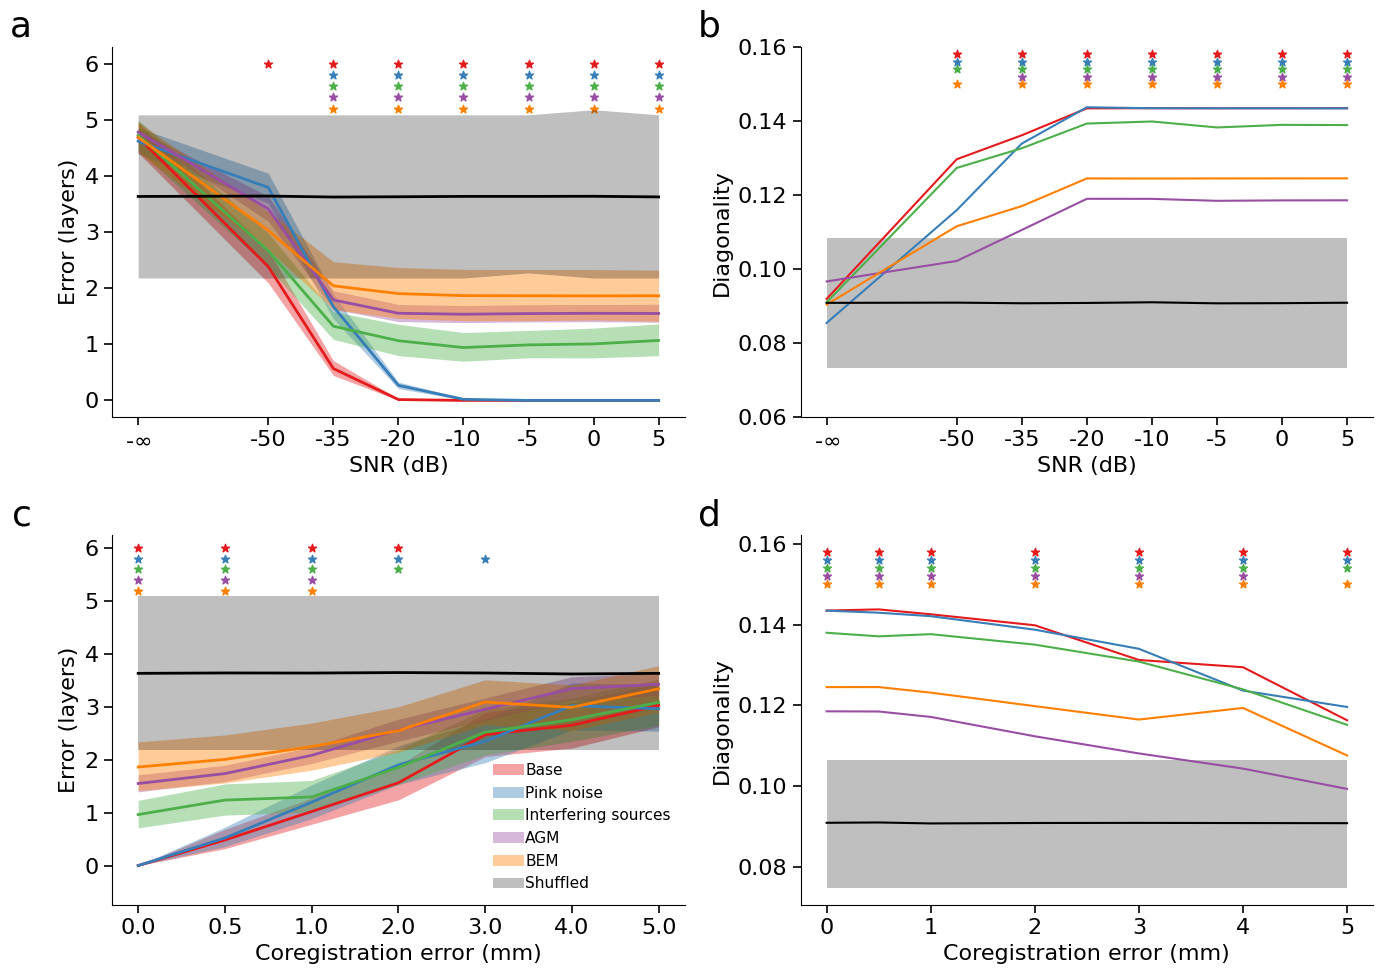

In [12]:
snrs_to_plot=[-500, -50, -35, -20]
fig=plt.figure(figsize=(2*7, 2*5), facecolor="white")
gs = GridSpec(2, 2)

ax=fig.add_subplot(gs[0,0])

for s_idx,sim_type in enumerate(sim_types):
    ax.plot(
        snr_ix, 
        snr_error_res[sim_type][:,0], 
        lw=2,
        color=sim_type_colors[sim_type]
    )
    ax.fill_between(
        snr_ix, 
        snr_error_res[sim_type][:,1], 
        snr_error_res[sim_type][:,2], 
        lw=0, 
        alpha=0.4, 
        color=sim_type_colors[sim_type],
        label=sim_type_labels[sim_type]
    )
    sig_levels=np.where(snr_p_values_error[sim_type]<0.05)[0]
    ax.scatter(
        snr_ix[sig_levels],
        np.tile(5.2+.2*(len(sim_types)-s_idx-1),len(sig_levels)),
        marker='*',
        color=sim_type_colors[sim_type]
    )

ax.plot(snr_ix, snr_shuf_error_res[:,0], color='k', lw=2)
ax.fill_between(
    snr_ix, 
    snr_shuf_error_res[:,1], 
    snr_shuf_error_res[:,2], 
    color='k', 
    lw=0, 
    alpha=0.25, 
    label='Shuffled'
)
    
ax.set_xticks(snr_ix)
ax.set_xticklabels(snr_tick_labels)
ax.set_ylabel("Error (layers)")
ax.set_xlabel("SNR (dB)")
add_subplot_label(ax, 'a', x=-.14, y=1.1)

ax=fig.add_subplot(gs[0,1])
for s_idx, sim_type in enumerate(sim_types):
    ax.plot(
        snr_ix,
        snr_dds[sim_type],
        color=sim_type_colors[sim_type],
        label=sim_type_labels[sim_type]
    )
    sig_levels=np.where(snr_p_vals_dds[sim_type]<0.05)[0]
    ax.scatter(
        snr_ix[sig_levels],
        np.tile(.15+.002*(len(sim_types)-s_idx-1),len(sig_levels)),
        marker='*',
        color=sim_type_colors[sim_type]
    )
ax.plot(snr_ix,np.mean(snr_permuted_dds,axis=-1),'k',label='shuffled')
ax.fill_between(snr_ix, snr_dds_95ci_shuf[0], snr_dds_95ci_shuf[1], color='k', lw=0, alpha=0.25, label='Shuffled')

# ax.legend(fontsize="x-small", loc='lower right')
ax.set_xticks(snr_ix)
_=ax.set_xticklabels(snr_tick_labels)
ax.set_ylim(0.06,0.16)
ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Diagonality')
add_subplot_label(ax, 'b', x=-.14, y=1.1)

coregerrs_to_plot=[0, 1, 2, 5]
ax=fig.add_subplot(gs[1,0])
for s_idx, sim_type in enumerate(sim_types):
    ax.plot(
        coreg_error_ix, 
        coreg_error_res[sim_type][:,0],
        lw=2,
        color=sim_type_colors[sim_type]
    )
    ax.fill_between(
        coreg_error_ix, 
        coreg_error_res[sim_type][:,1], 
        coreg_error_res[sim_type][:,2], 
        lw=0, 
        alpha=0.4, 
        color=sim_type_colors[sim_type],
        label=sim_type_labels[sim_type]
    )
    sig_levels=np.where(coreg_p_values_error[sim_type]<0.05)[0]
    ax.scatter(
        coreg_error_ix[sig_levels],
        np.tile(5.2+.2*(len(sim_types)-s_idx-1),len(sig_levels)),
        marker='*',
        color=sim_type_colors[sim_type]
    )

ax.plot(coreg_error_ix, coreg_error_shuf_error_res[:,0], color='k', lw=2)
ax.fill_between(coreg_error_ix, coreg_error_shuf_error_res[:,1], coreg_error_shuf_error_res[:,2], color='k', lw=0, alpha=0.25,label='Shuffled')
    
ax.set_ylim([-.75, 6.25])
ax.set_xticks(coreg_error_ix)
ax.set_xticklabels(coreg_tick_labels)
ax.set_ylabel("Error (layers)")
ax.set_xlabel("Coregistration error (mm)")
ax.legend(fontsize="x-small", loc='lower right')
add_subplot_label(ax, 'c', x=-.14, y=1.1)

ax=fig.add_subplot(gs[1,1])
for s_idx, sim_type in enumerate(sim_types):
    ax.plot(
        coreg_range,
        coreg_dds[sim_type],
        color=sim_type_colors[sim_type],
        label=sim_type_labels[sim_type]
    )
    sig_levels=np.where(coreg_p_vals_dds[sim_type]<0.05)[0]
    ax.scatter(
        coreg_range[sig_levels],
        np.tile(.15+.002*(len(sim_types)-s_idx-1),len(sig_levels)),
        marker='*',
        color=sim_type_colors[sim_type]
    )
ax.plot(coreg_range,np.mean(coreg_permuted_dds,axis=-1),'k')
ax.fill_between(coreg_range, coreg_dds_95ci_shuf[0], coreg_dds_95ci_shuf[1], color='k', lw=0, alpha=0.25, label='Shuffled')

ax.set_xlabel('Coregistration error (mm)')
ax.set_ylabel('Diagonality')
add_subplot_label(ax, 'd', x=-.14, y=1.1)

plt.tight_layout()
plt.savefig(f"figure_07_robustness.pdf")

In [13]:
data={
    'sim_type': [],
    'snr': [],
    'sim_mean': [],
    'sim_CI_low': [],
    'sim_CI_high': [],
    'p': []
}
for sim_type in sim_types:
    for snr_idx in range(snr_error_res[sim_type].shape[0]):
        data['sim_type'].append(sim_type)
        data['snr'].append(snr_range[snr_idx])
        data['sim_mean'].append(snr_error_res[sim_type][snr_idx,0])
        data['sim_CI_low'].append(snr_error_res[sim_type][snr_idx,1])
        data['sim_CI_high'].append(snr_error_res[sim_type][snr_idx,2])
        data['p'].append(snr_p_values_error[sim_type][snr_idx])
        
for snr_idx in range(snr_shuf_error_res.shape[0]):
    data['sim_type'].append('shuffled')
    data['snr'].append(snr_range[snr_idx])
    data['sim_mean'].append(snr_shuf_error_res[snr_idx,0])
    data['sim_CI_low'].append(snr_shuf_error_res[snr_idx,1])
    data['sim_CI_high'].append(snr_shuf_error_res[snr_idx,2])
    data['p'].append(np.nan)
df=pd.DataFrame(data)
df.to_csv(f'source_data_fig_07a.csv', index=False)

In [15]:
data={
    'sim_type': [],
    'snr': [],
    'sim_mean': [],
    'sim_CI_low': [],
    'sim_CI_high': [],
    'p': []
}
for sim_type in sim_types:
    for snr_idx in range(len(snr_dds[sim_type])):
        data['sim_type'].append(sim_type)
        data['snr'].append(snr_range[snr_idx])
        data['sim_mean'].append(snr_dds[sim_type][snr_idx])
        data['sim_CI_low'].append(np.nan)
        data['sim_CI_high'].append(np.nan)
        data['p'].append(snr_p_vals_dds[sim_type][snr_idx])
        
for snr_idx in range(snr_permuted_dds.shape[0]):
    data['sim_type'].append('shuffled')
    data['snr'].append(snr_range[snr_idx])
    data['sim_mean'].append(np.mean(snr_permuted_dds,axis=-1)[snr_idx])
    data['sim_CI_low'].append(snr_dds_95ci_shuf[0])
    data['sim_CI_high'].append(snr_dds_95ci_shuf[1])
    data['p'].append(np.nan)
df=pd.DataFrame(data)
df.to_csv(f'source_data_fig_07b.csv', index=False)

In [16]:
data={
    'sim_type': [],
    'coreg_err': [],
    'sim_mean': [],
    'sim_CI_low': [],
    'sim_CI_high': [],
    'p': []
}
for sim_type in sim_types:
    for coreg_idx in range(coreg_error_res[sim_type].shape[0]):
        data['sim_type'].append(sim_type)
        data['coreg_err'].append(coreg_range[coreg_idx])
        data['sim_mean'].append(coreg_error_res[sim_type][coreg_idx,0])
        data['sim_CI_low'].append(coreg_error_res[sim_type][coreg_idx,1])
        data['sim_CI_high'].append(coreg_error_res[sim_type][coreg_idx,2])
        data['p'].append(coreg_p_values_error[sim_type][coreg_idx])
        
for snr_idx in range(coreg_error_shuf_error_res.shape[0]):
    data['sim_type'].append('shuffled')
    data['coreg_err'].append(coreg_range[coreg_idx])
    data['sim_mean'].append(coreg_error_shuf_error_res[coreg_idx,0])
    data['sim_CI_low'].append(coreg_error_shuf_error_res[coreg_idx,1])
    data['sim_CI_high'].append(coreg_error_shuf_error_res[coreg_idx,2])
    data['p'].append(np.nan)
df=pd.DataFrame(data)
df.to_csv(f'source_data_fig_07c.csv', index=False)

In [17]:
data={
    'sim_type': [],
    'coreg_err': [],
    'sim_mean': [],
    'sim_CI_low': [],
    'sim_CI_high': [],
    'p': []
}
for sim_type in sim_types:
    for coreg_idx in range(len(coreg_dds[sim_type])):
        data['sim_type'].append(sim_type)
        data['coreg_err'].append(coreg_range[coreg_idx])
        data['sim_mean'].append(coreg_dds[sim_type][coreg_idx])
        data['sim_CI_low'].append(np.nan)
        data['sim_CI_high'].append(np.nan)
        data['p'].append(coreg_p_vals_dds[sim_type][coreg_idx])
        
for coreg_idx in range(coreg_permuted_dds.shape[0]):
    data['sim_type'].append('shuffled')
    data['coreg_err'].append(coreg_range[coreg_idx])
    data['sim_mean'].append(np.mean(coreg_permuted_dds,axis=-1)[coreg_idx])
    data['sim_CI_low'].append(coreg_dds_95ci_shuf[0])
    data['sim_CI_high'].append(coreg_dds_95ci_shuf[1])
    data['p'].append(np.nan)
df=pd.DataFrame(data)
df.to_csv(f'source_data_fig_07d.csv', index=False)